## 📢 Caso: Elección del método anticonceptivo

Grupo # 4:



*   Leimar Torres
*   Juan Hurtado
*   Oscar Montaño


Vínculo al dataset:
https://archive.ics.uci.edu/dataset/30/contraceptive+method+choice

Este conjunto de datos es un subconjunto de la Encuesta Nacional de Prevalencia de Anticonceptivos de Indonesia de 1987. Las muestras son mujeres casadas que no estaban embarazadas o que desconocen si lo estaban en el momento de la entrevista. El problema consiste en predecir la elección actual de un método anticonceptivo (no uso, métodos a largo plazo o métodos a corto plazo) por parte de una mujer en función de sus características demográficas y socioeconómicas.



**Etapa 1: Entendimiento de los datos**

* Identificar número de muestras y atributos
* Identificar el tipo de cada atributo
* Calcular medidas de centralidad y dispersión por cada atributo de acuerdo a su tipo (hacer gráfico de cajas y bigotes por atributo, diagrama de dispersión u otro diagrama acorde al tipo del atributo que ilustre el comportamiento de los datos)
* Calcular la matriz de correlación entre los atributos de entrada
* Determinar el grado de balanceo entre los valores del atributo objetivo
* Identificar número de datos faltantes por clase
* Identificar número de datos atípicos por clase. Para esto, te recomendamos que explores la librería https://github.com/yzhao062/pyod que implementa distintas metodologías de identificación de datos atípicos.

**Información variable adicional**

   1. Edad de la esposa (numérica)
   2. Educación de la esposa (categórica) 1 = baja, 2, 3, 4 = alta
   3. Educación del esposo (categórica) 1 = baja, 2, 3, 4 = alta
   4. Número de hijos nacidos (numérica)
   5. Religión de la esposa (binaria) 0 = No islámica, 1 = islam
   6. ¿Trabaja la esposa ahora? (binaria) 0 = Sí, 1 = No
   7. Ocupación del esposo (categórica) 1, 2, 3, 4
   8. Índice de nivel de vida (categórico) 1 = baja, 2, 3, 4 = alta
   9. Exposición a los medios (binaria) 0 = Buena, 1 = Mala
   10. Método anticonceptivo utilizado (atributo de clase) 1 = No uso, 2 = Largo plazo, 3 = Corto plazo

In [ ]:
pip install ucimlrepo

### Carga de librerías y lectura del archivo que contiene los datos

In [ ]:
import numpy as np
import pandas as pd
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import copy

In [ ]:
contraceptive_method_choice = fetch_ucirepo(id=30)

### Información de variables

In [ ]:
print(contraceptive_method_choice.variables)

                       name     role         type      demographic  \
0                  wife_age  Feature      Integer              Age   
1                  wife_edu  Feature  Categorical  Education Level   
2               husband_edu  Feature  Categorical  Education Level   
3              num_children  Feature      Integer            Other   
4             wife_religion  Feature       Binary            Other   
5              wife_working  Feature       Binary       Occupation   
6        husband_occupation  Feature  Categorical       Occupation   
7  standard_of_living_index  Feature  Categorical             None   
8            media_exposure  Feature       Binary             None   
9      contraceptive_method   Target  Categorical             None   

  description units missing_values  
0        None  None             no  
1        None  None             no  
2        None  None             no  
3        None  None             no  
4        None  None             no  
5      

In [ ]:
print(contraceptive_method_choice.metadata)

{'uci_id': 30, 'name': 'Contraceptive Method Choice', 'repository_url': 'https://archive.ics.uci.edu/dataset/30/contraceptive+method+choice', 'data_url': 'https://archive.ics.uci.edu/static/public/30/data.csv', 'abstract': 'Dataset is a subset of the 1987 National Indonesia Contraceptive Prevalence Survey.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1473, 'num_features': 9, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Education Level', 'Other', 'Occupation'], 'target_col': ['contraceptive_method'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C59W2D', 'creators': ['Tjen-Sien Lim'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a subset of the 1987 National Indonesia Contraceptive Prevalence Survey. The samples are married women who were either

In [ ]:
X = contraceptive_method_choice.data.features
y = contraceptive_method_choice.data.targets

In [ ]:
df = pd.concat([X, y], axis=1)
df.head(500)

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure,contraceptive_method
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1
...,...,...,...,...,...,...,...,...,...,...
495,48,4,4,4,0,1,1,4,0,2
496,31,4,4,3,1,1,1,4,0,2
497,26,4,4,1,0,1,2,4,0,2
498,44,4,4,5,1,0,1,4,0,2


### Número de muestras y atributos

In [ ]:
df.shape

(1473, 10)

### Tipo de cada atributo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   wife_age                  1473 non-null   int64
 1   wife_edu                  1473 non-null   int64
 2   husband_edu               1473 non-null   int64
 3   num_children              1473 non-null   int64
 4   wife_religion             1473 non-null   int64
 5   wife_working              1473 non-null   int64
 6   husband_occupation        1473 non-null   int64
 7   standard_of_living_index  1473 non-null   int64
 8   media_exposure            1473 non-null   int64
 9   contraceptive_method      1473 non-null   int64
dtypes: int64(10)
memory usage: 115.2 KB


### Medidas de centralidad y dispersión por cada atributo de acuerdo a su tipo

In [ ]:
df.mode()

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure,contraceptive_method
0,25.0,4.0,4.0,1,1.0,1.0,3.0,4.0,0.0,1.0
1,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure,contraceptive_method
count,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000
mean,32.538357,2.958588,3.429735,3.261371,0.850645,0.749491,2.137814,3.133741,0.073999,1.919891
std,8.227245,1.014994,0.816349,2.358549,0.356559,0.433453,0.864857,0.976161,0.261858,0.876376
min,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,26.000000,2.000000,3.000000,1.000000,1.000000,0.000000,1.000000,3.000000,0.000000,1.000000
50%,32.000000,3.000000,4.000000,3.000000,1.000000,1.000000,2.000000,3.000000,0.000000,2.000000
75%,39.000000,4.000000,4.000000,4.000000,1.000000,1.000000,3.000000,4.000000,0.000000,3.000000
max,49.000000,4.000000,4.000000,16.000000,1.000000,1.000000,4.000000,4.000000,1.000000,3.000000


### Gráfico de cajas y bigotes por atributo

### Distribución de la variable age

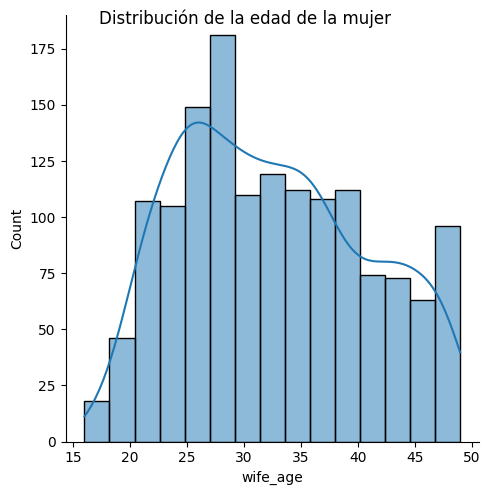

In [ ]:
sns.displot(
    x='wife_age',
    data=df,
    kde=True ## Agrega curva de densidad
)

plt.suptitle('Distribución de la edad de la mujer')
plt.show()

* Se observa alta densidad en edades centrales entre 25 y 40 años
* Presenta un ligero sesgo a la derecha (cola hacia edades mayores)
* No es perfectamente normal, pero tampoco extremadamente asimétrica
* No hay evidencia clara de outliers severos


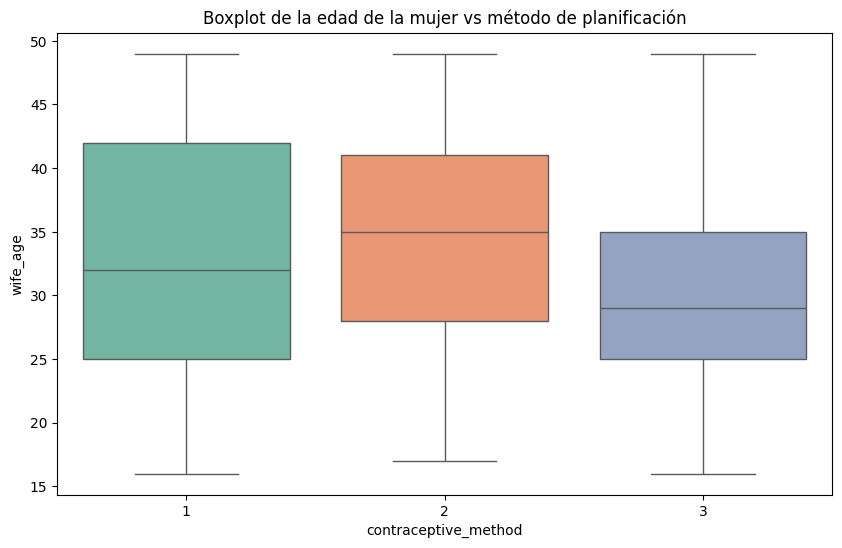

In [ ]:

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df,
    x='contraceptive_method',
    y='wife_age',
    hue='contraceptive_method',
    palette='Set2',
    legend=False
)

plt.title('Boxplot de la edad de la mujer vs método de planificación')
plt.show()

#1 No usa, 2 = Largo plazo, 3 = Corto plazo

### De acuerdo con la mediana del gráfico anterior, se infiere que que las mujeres más jóvenes prefieren métodos a corto plazo

In [ ]:
df.groupby('contraceptive_method')['wife_age'].median()

,wife_age
contraceptive_method,
1,32.0
2,35.0
3,29.0


###

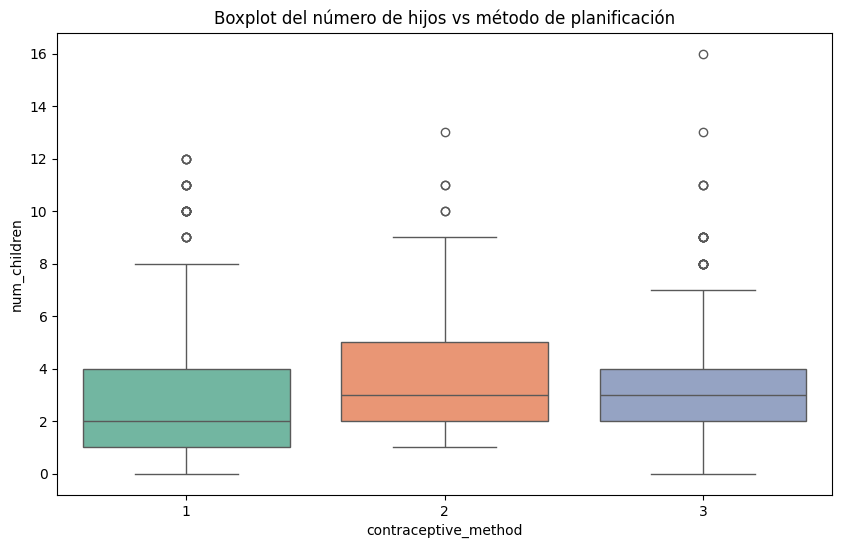

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x='contraceptive_method',
    y='num_children',
    hue='contraceptive_method',   # 🔑 clave
    palette='Set2',
    legend=False                  # 🔕 evita leyenda redundante
)

plt.title('Boxplot del número de hijos vs método de planificación')
plt.show()

### Resulta interesante que el promedio hijos más bajo corresponda a las mujeres que no usan algunos de los métodos

In [ ]:
df.groupby('contraceptive_method')['num_children'].mean()

,num_children
contraceptive_method,
1,2.934817
2,3.738739
3,3.352250


### Resulta interesante

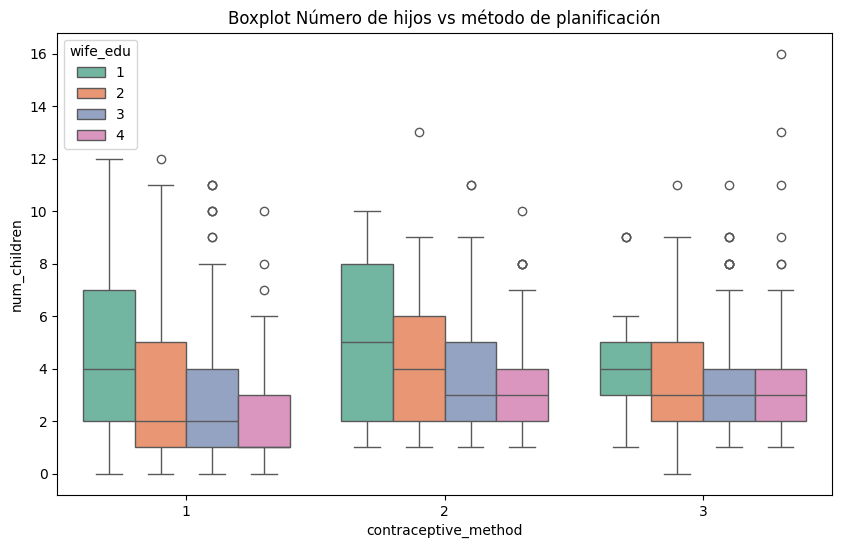

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x='contraceptive_method',
    y='num_children',
    hue='wife_edu',   # 🔑 clave
    palette='Set2',
    legend=True                  # 🔕 evita leyenda redundante
)

plt.title('Boxplot Número de hijos vs método de planificación')
plt.show()

#1 = baja,


### Para todos los métodos anticonceptivos analizados, se observa que a medida que aumenta el nivel educativo de las mujeres, el número promedio de hijos tiende a disminuir.


In [ ]:
#df.groupby('wife_edu')[['contraceptive_method', 'num_children']].mean()

df.groupby('wife_edu')['num_children'].mean()

,num_children
wife_edu,
1,4.421053
2,3.508982
3,3.234146
4,2.831889


###

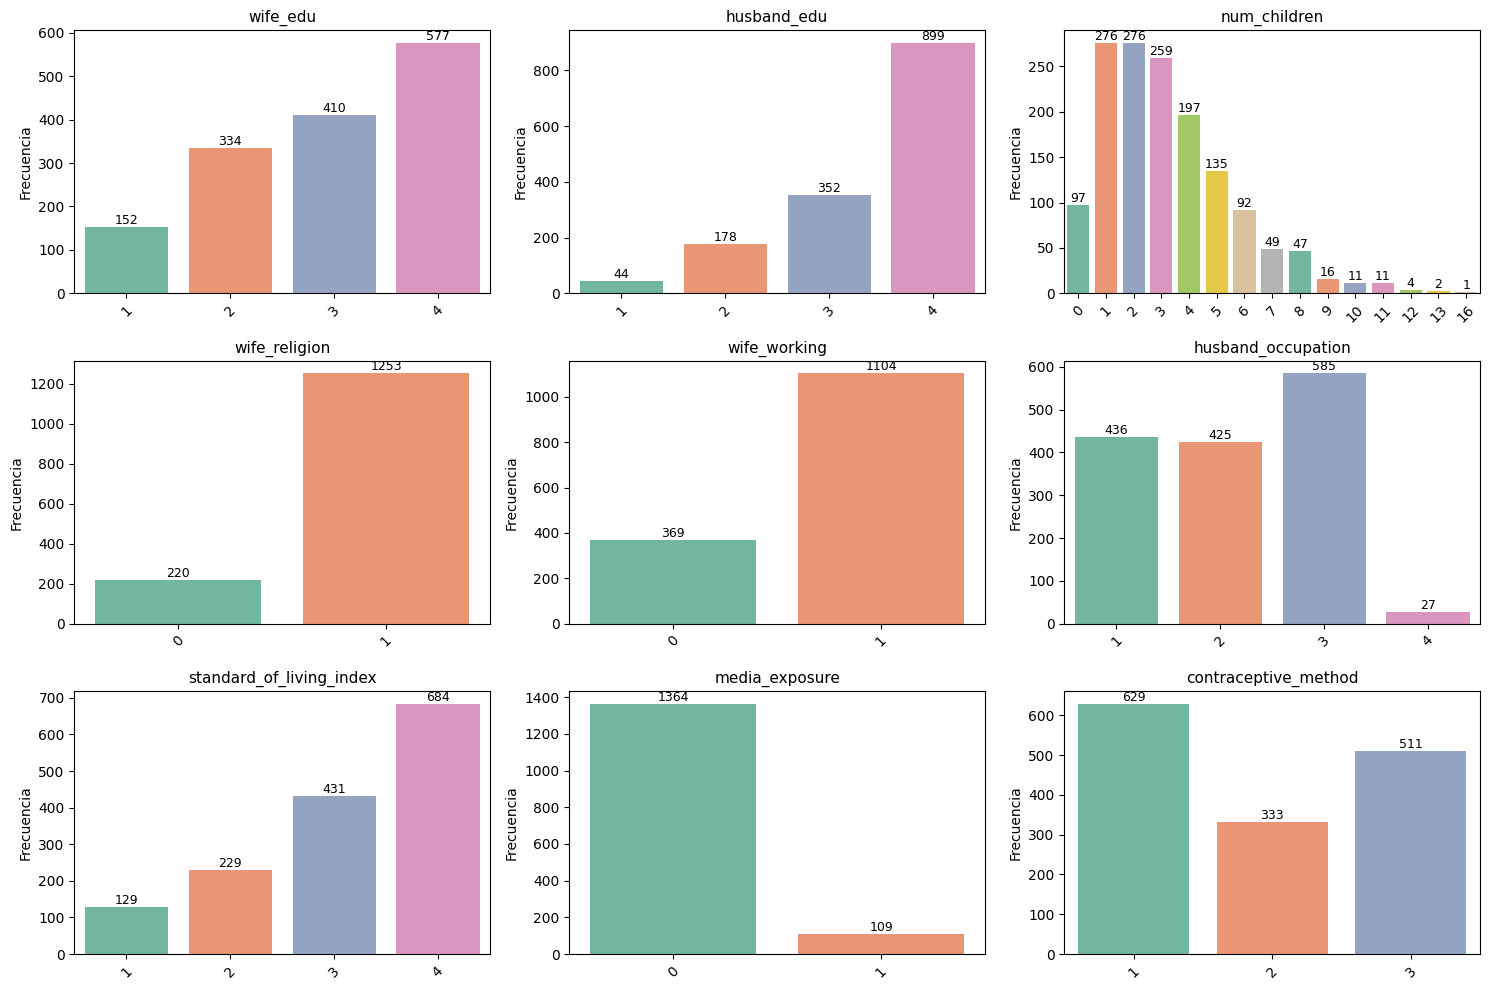

In [ ]:
variables = [
    'wife_edu',
    'husband_edu',
    'num_children',
    'wife_religion',
    'wife_working',
    'husband_occupation',
    'standard_of_living_index',
    'media_exposure',
    'contraceptive_method'
]

plt.figure(figsize=(15, 10))
for i, var in enumerate(variables, 1):
    plt.subplot(3, 3, i)

    ax = sns.countplot(
        data=df,
        x=var,
        hue=var,
        palette='Set2',
        legend=False
    )

    ax.set_title(var, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    plt.xticks(rotation=45)

    # Etiquetas
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()


### Se observan valores atípicos en la variable num_children

### Matriz de correlación entre los atributos de entrada

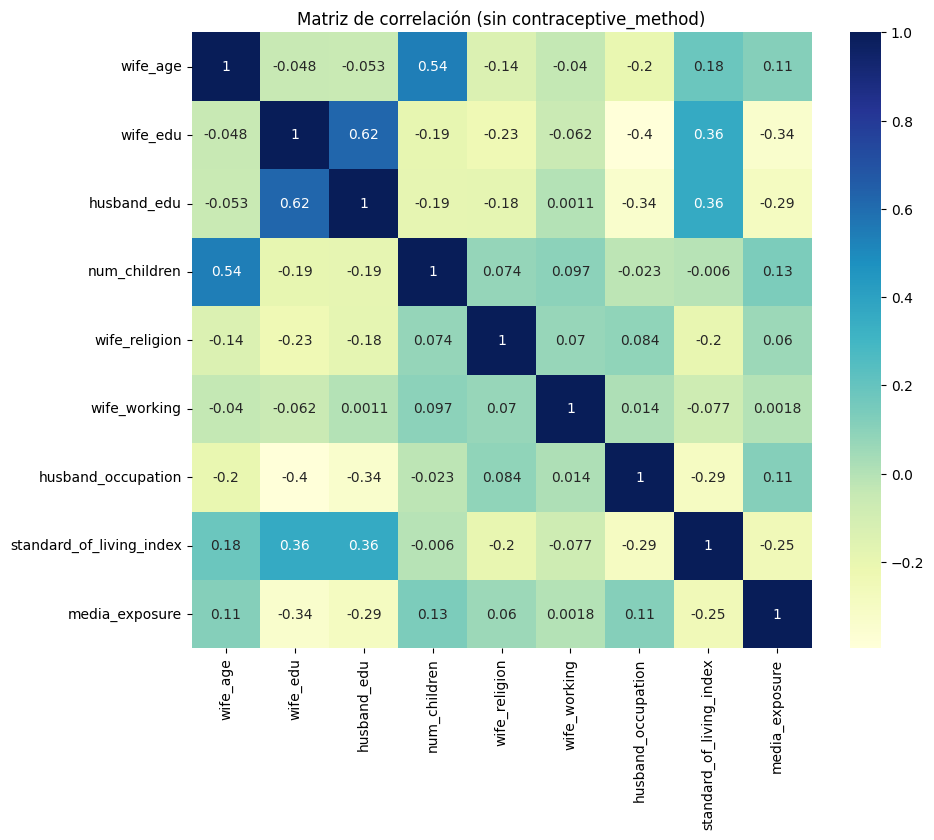

In [ ]:

plt.figure(figsize=(10, 8))
sns.heatmap(
    df.drop(columns=['contraceptive_method']).corr(),
    annot=True,
    cmap='YlGnBu'
)

plt.title('Matriz de correlación (sin contraceptive_method)')
plt.show()

### No hay correlaciones superiores a 0.85, por lo que no se suguiere multicolinealidad entre las variables explicativas

### Registros por clase de variable objetivo

In [ ]:
df['contraceptive_method'].value_counts()

,count
contraceptive_method,
1,629
3,511
2,333


### Número de datos faltantes por clase

In [ ]:
df.isnull().sum()

,0
wife_age,0
wife_edu,0
husband_edu,0
num_children,0
wife_religion,0
wife_working,0
husband_occupation,0
standard_of_living_index,0
media_exposure,0
contraceptive_method,0


### El dataset no presenta datos faltantes 🙏🙏🙏

In [ ]:
##cols = ['wife_age', 'wife_edu', 'husband_edu', 'num_children']

### Transformando datos categóricos 🎯
### Se transforma a binarias todas la variables que se agrupan así: 1 = bajo, 2,3,4 alto. Estas son:

1.   Wife's education  
2.   Husband's education
3.   Standard-of-living index





In [ ]:
df_trans_cat = copy.deepcopy(df)

In [ ]:
df_trans_cat.columns

Index(['wife_age', 'wife_edu', 'husband_edu', 'num_children', 'wife_religion',
       'wife_working', 'husband_occupation', 'standard_of_living_index',
       'media_exposure', 'contraceptive_method'],
      dtype='object')

In [ ]:
df_trans_cat['wife_edu'] = df_trans_cat['wife_edu'].apply(lambda x: 1 if x > 1 else 0)
df_trans_cat['husband_edu'] = df_trans_cat['husband_edu'].apply(lambda x: 1 if x > 1 else 0)
df_trans_cat['standard_of_living_index'] = df_trans_cat['standard_of_living_index'].apply(lambda x: 1 if x > 1 else 0)

#lambda x: 0 if x == 1 else 1
#Si x es igual a 1 → devolver 0
#En cualquier otro caso → devolver 1


In [ ]:
df_trans_cat.head(5)

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure,contraceptive_method
0,24,1,1,3,1,1,2,1,0,1
1,45,0,1,10,1,1,3,1,0,1
2,43,1,1,7,1,1,3,1,0,1
3,42,1,1,9,1,1,3,1,0,1
4,36,1,1,8,1,1,3,1,0,1


### Detectando Datos atípicos por clase usando la librería PyOD, Modelo: Isolation Forest 🎯

Isolation Forest es un método no supervisado para la detección de valores atípicos que se basa en el principio de que las observaciones anómalas son más fáciles de aislar que las normales. El algoritmo utiliza particiones aleatorias del espacio de variables para identificar observaciones con patrones poco frecuentes. No asume ninguna distribución de los datos, es robusto frente al ruido y eficiente computacionalmente, lo que lo hace adecuado para conjuntos de datos multivariados y de alta dimensión. En este trabajo se emplea como una herramienta exploratoria para identificar observaciones atípicas antes del modelado predictivo.

Entre sus principales características se destacan:



*   No paramétrico: no asume ninguna distribución específica de los datos.
*   Robusto: tolera ruido y valores extremos sin verse significativamente afectado.
*  Escalable a alta dimensionalidad: mantiene un buen desempeño incluso cuando el número de variables es elevado.
*  Escalable a alta dimensionalidad: mantiene un buen desempeño incluso cuando el número de variables es elevado.
*  Eficiente computacionalmente:  El tiempo de ejecución crece de forma moderada con el tamaño del conjunto de datos, permitiendo su aplicación eficiente en conjuntos de datos de tamaño mediano y grande.

In [ ]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 13.7 MB/s eta 0:00:00


### Todas las variables menos la variable objetivo

In [ ]:
df_atip = copy.deepcopy(df_trans_cat)

In [ ]:
X = df_atip.drop(columns=['contraceptive_method'])

### Escalar los datos (OBLIGATORIO)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Implementando Modelo Isolation Forest

In [ ]:
from pyod.models.iforest import IForest

model = IForest(
    contamination=0.05,   # asumimos 5% de outliers
    random_state=42
)

model.fit(X_scaled)

IForest(behaviour='old', bootstrap=False, contamination=0.05,
    max_features=1.0, max_samples='auto', n_estimators=100, n_jobs=1,
    random_state=42, verbose=0)

### Detección de outliers

In [ ]:
outliers = model.predict(X_scaled)

In [ ]:
df_atip['outlier'] = outliers

In [ ]:
df_atip['outlier'].value_counts()
# outlier  = 1

,count
outlier,
0,1399
1,74


### Ver outlier detectados en todo el dataset

In [ ]:
df_atip[df_atip['outlier'] == 1].head()

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure,contraceptive_method,outlier
9,45,0,0,8,1,1,2,1,1,1,1
10,38,0,1,2,1,0,3,1,1,1,1
16,48,0,0,7,1,1,2,1,0,1,1
19,39,1,0,5,1,1,2,0,1,1,1
20,26,1,1,1,1,0,4,0,0,1,1


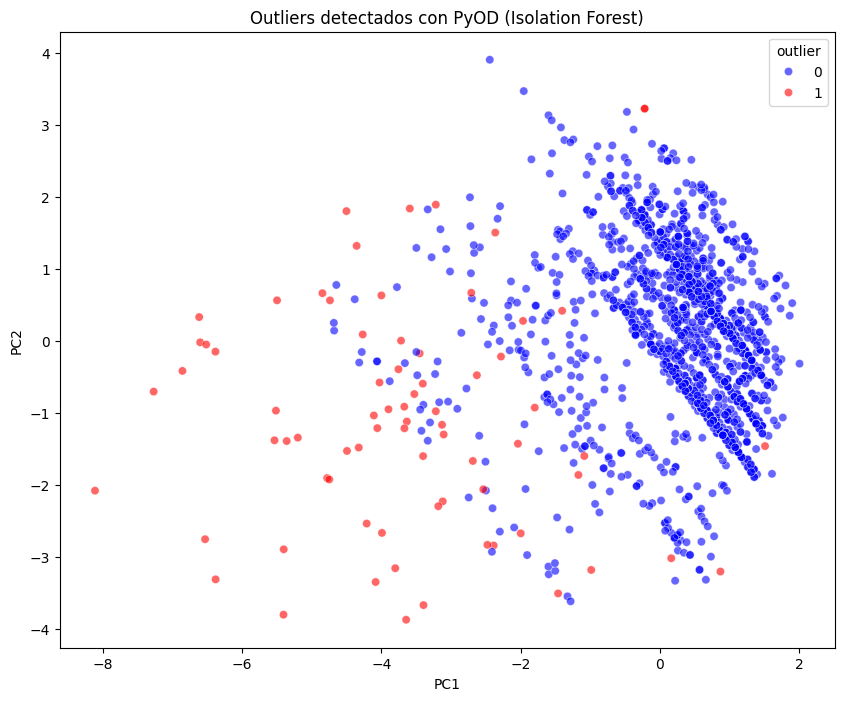

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['outlier'] = df_atip['outlier']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='outlier',
    palette={0: 'blue', 1: 'red'},
    alpha=0.6
)

plt.title('Outliers detectados con PyOD (Isolation Forest)')
plt.show()

### **Interpretación**

* 74 observaciones tiene una combinación de valores poco frecuente en el dataset.

### 👌 Dataset sin outlier


In [ ]:
df_sin_outliers = df_atip[df_atip['outlier'] == 0]

In [ ]:
df_sin_outliers.shape

(1399, 11)

### Balanceo del dataset de acuerdo con la clase mayoritaría

In [ ]:
g = df_sin_outliers.groupby('contraceptive_method')
dataBal = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))
dataBal

/tmp/ipython-input-3912933751.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataBal = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))


wife_age  wife_edu  husband_edu  num_children  \
contraceptive_method                                                      
1                    0          25         1            1             2   
                     1          20         1            1             2   
                     2          44         1            1             4   
                     3          20         1            1             2   
                     4          24         1            1             1   
...                            ...       ...          ...           ...   
3                    321        22         1            1             2   
                     322        28         1            1             4   
                     323        45         0            1             3   
                     324        22         1            1             2   
                     325        38         1            1             3   

                          wife_religion  wife_working  husband_occupation  \
contraceptive_method                                                        
1                    0                1             1                   3   
                     1                1             1                   2   
                     2                1             0                   1   
                     3                1             1                   3   
                     4                1             0                   4   
...                                 ...           ...                 ...   
3                    321              1             1                   2   
                     322              1             1                   3   
                     323              1             1                   3   
                     324              1             1                   2   
                     325              1             1                   2   

                          standard_of_living_index  media_exposure  \
contraceptive_method                                                 
1                    0                           1               0   
                     1                           1               1   
                     2                           1               0   
                     3                           1               0   
                     4                           1               0   
...                                            ...             ...   
3                    321                         1               0   
                     322                         1               0   
                     323                         1               0   
                     324                         1               0   
                     325                         1               0   

                          contraceptive_method  outlier  
contraceptive_method                                     
1                    0                       1        0  
                     1                       1        0  
                     2                       1        0  
                     3                       1        0  
                     4                       1        0  
...                                        ...      ...  
3                    321                     3        0  
                     322                     3        0  
                     323                     3        0  
                     324                     3        0  
                     325                     3        0  

[978 rows x 11 columns]

In [ ]:
dataBal['contraceptive_method'].value_counts()

,count
contraceptive_method,
1,326
2,326
3,326


### Entrenamiento de un modelo de regresión logística 🎯

### Con Conjunto original (Transformando datos categóricos) 🚀

### Dividiendo el set de datos en entrenamiento y prueba

In [ ]:
X = df_trans_cat.drop(columns='contraceptive_method')  # variables predictoras
y = df_trans_cat['contraceptive_method']               # variable objetivo

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

(1031, 9) (1031,)
(442, 9) (442,)


In [ ]:
from sklearn.linear_model import LogisticRegression

logisticRegr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

logisticRegr.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

### Evaluando el modelo

In [ ]:
from sklearn.metrics import classification_report

y_pred = logisticRegr.predict(X_test)

#classification_report(y_test, y_pred)

### Matriz de confusión

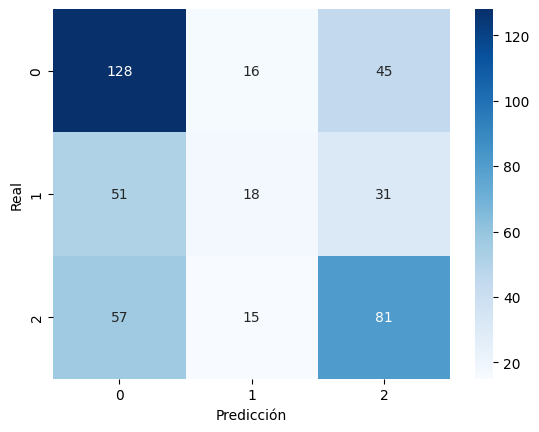

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
#from google.colab import files

#df.to_excel("df_anticoncepción.xlsx", index=False)
#files.download("df_anticoncepción.xlsx")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

def train_evaluate(df, target='contraceptive_method'):

    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_macro': precision_score(y_test, y_pred, average='macro'),
        'Recall_macro': recall_score(y_test, y_pred, average='macro')
    }

In [ ]:
results = {}

results['Original (df_trans_cat)'] = train_evaluate(df_trans_cat)
results['Sin outliers (df_sin_outliers)'] = train_evaluate(df_sin_outliers)
results['Balanceado (dataBal)'] = train_evaluate(dataBal)

### Tabla Resumen de resultados de resultados de modelos

In [ ]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision_macro,Recall_macro
Original (df_trans_cat),0.513575,0.475214,0.462220
Sin outliers (df_sin_outliers),0.488095,0.483196,0.455715
Balanceado (dataBal),0.527211,0.528170,0.527211


#### Aplicando PCA al dataset dataBal

In [ ]:
X = dataBal.drop(columns=['contraceptive_method'])
y = dataBal['contraceptive_method']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### Escalado de variables (OBLIGATORIO para PCA)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Aplicar PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### ¿Cuánta varianza explica PCA?



In [ ]:
print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

print("Varianza acumulada:")
print(pca.explained_variance_ratio_.sum())

Varianza explicada por componente:
[0.18775219 0.15416992 0.12553951 0.11495805 0.10466409 0.09907922
 0.09260976 0.07980439]
Varianza acumulada:
0.9585771267970746


In [ ]:

logistic_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

logistic_model.fit(X_train_pca, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = logistic_model.predict(X_test_pca)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.445578231292517

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.46      0.27      0.34        98
           2       0.46      0.57      0.51        98
           3       0.43      0.50      0.46        98

    accuracy                           0.45       294
   macro avg       0.45      0.45      0.43       294
weighted avg       0.45      0.45      0.43       294



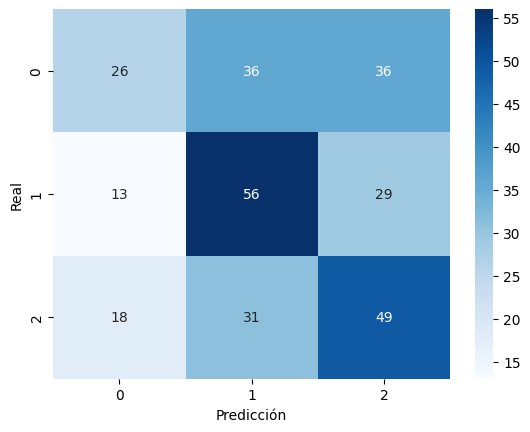

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Los resultados muestran que el balanceo de clases tiene un impacto positivo en el desempeño del modelo, mejorando significativamente las métricas macro-promedio de precisión y recall. Sin embargo, la incorporación de PCA sobre el conjunto balanceado conduce a una disminución del desempeño, especialmente en la identificación de la clase “No uso”, lo que sugiere que las variables originales contienen información discriminativa relevante que se pierde al aplicar la transformación. En consecuencia, el modelo entrenado sobre el dataset balanceado sin PCA representa la mejor alternativa entre los escenarios evaluados.